# Hybrid Retrieval Evaluation

Week 5 extends the week 4 semantic index with a sparse keyword leg and fuses the two.
This notebook shows what fusion buys, using the shared `HybridSearchEngine` from
`scripts/hybrid_lib.py` and the labelled query set in `data/eval/queries.json`.

The index is **SQLite + FAISS**: `index/hybrid.db` holds paper metadata, the chunk table and
an FTS5 full-text index; `index/faiss.index` holds the 914 chunk embeddings from week 4,
reused unchanged. A chunk's FAISS row id is stored in SQLite, so the two halves join
by arithmetic.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "scripts"))

import pandas as pd
import matplotlib.pyplot as plt

from hybrid_lib import HybridSearchEngine
from evaluate_retrieval import load_queries, build_methods, evaluate, sweep_alpha

pd.set_option("display.max_colwidth", 60)

engine = HybridSearchEngine()
queries = load_queries()

print("Index:", engine.stats())
print(f"Evaluation set: {len(queries)} queries, "
      f"{sum(len(q['relevant_chunk_ids']) for q in queries)} labelled chunks")

C:\Users\chenk\inferenceAI\arxiv-rag-search\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5188.79it/s]

Index: {'documents': 50, 'chunks': 914, 'faiss_ntotal': 914, 'faiss_dim': 384}
Evaluation set: 15 queries, 16 labelled chunks


## 1. What the two legs disagree about

Both legs search the same 914 chunks, but they rank them on different evidence. The
clearest way to see this is a query where one leg fails outright.

`q04` asks about **All-to-All metadata and small-GEMM fragmentation** — technical
strings that appear verbatim in exactly one chunk of the MoE survey. The gold chunk is
marked `<<<` below.

In [2]:
def compare(query, gold_chunk_ids, k=5):
    """Show the same query's top-k under each leg, side by side."""
    gold = set(gold_chunk_ids)
    legs = {
        "vector-only": engine.search_vector_only(query, k=k),
        "fts5-only":   engine.search_keyword_only(query, k=k, kw_backend="fts5"),
        "hybrid (a=0.5)": engine.search(query, k=k, method="weighted", alpha=0.5),
    }
    print(f"query: {query!r}")
    print(f"gold:  {sorted(gold)}\n")
    for name, results in legs.items():
        hit = next((r["rank"] for r in results if r["chunk_id"] in gold), None)
        print(f"--- {name}  (gold at rank {hit if hit else '> %d' % k}) ---")
        for r in results:
            mark = " <<<" if r["chunk_id"] in gold else ""
            print(f"  [{r['rank']}] {r['chunk_id']:18} fused={r['fused_score']:.4f}"
                  f"  v={r['vec_score']:.3f} k={r['kw_score']:.3f}{mark}")
        print()

q04 = next(q for q in queries if q["qid"] == "q04")
compare(q04["query"], q04["relevant_chunk_ids"])

query: 'All-to-All metadata and small-GEMM fragmentation when experts get too few tokens'
gold:  ['2608.08650_9']

--- vector-only  (gold at rank > 5) ---
  [1] 2608.08650_15      fused=1.0000  v=1.000 k=0.000
  [2] 2608.08650_12      fused=0.8166  v=0.817 k=0.000
  [3] 2608.07594_35      fused=0.7683  v=0.768 k=0.000
  [4] 2608.07594_29      fused=0.6905  v=0.691 k=0.000
  [5] 2608.07727_2       fused=0.6018  v=0.602 k=0.000

--- fts5-only  (gold at rank 2) ---
  [1] 2608.08650_8       fused=1.0000  v=0.000 k=1.000
  [2] 2608.08650_9       fused=0.9270  v=0.000 k=0.927 <<<
  [3] 2608.08650_5       fused=0.6600  v=0.000 k=0.660
  [4] 2608.08650_6       fused=0.5711  v=0.000 k=0.571
  [5] 2608.08650_16      fused=0.5393  v=0.000 k=0.539

--- hybrid (a=0.5)  (gold at rank 3) ---
  [1] 2608.08650_15      fused=0.6194  v=1.000 k=0.239
  [2] 2608.08650_8       fused=0.6090  v=0.218 k=1.000
  [3] 2608.08650_9       fused=0.5583  v=0.190 k=0.927 <<<
  [4] 2608.08650_12      fused=0.4144  v=0.

Vector search misses it entirely: the query's phrasing is close to a dozen chunks that
*discuss* expert parallelism, and the embedding has no way to privilege the one that
names these particular mechanisms. The keyword leg puts it at rank 2, and fusion carries
it into the top 3.

The reverse case, `q05`, is a pure paraphrase — the answer's own vocabulary
("reopening", "absorbing unmasking") is deliberately absent from the query:

In [3]:
q05 = next(q for q in queries if q["qid"] == "q05")
compare(q05["query"], q05["relevant_chunk_ids"])

query: 'once a position has been filled in it can never be revised, so what repair is left'
gold:  ['2608.08082_60']

--- vector-only  (gold at rank 1) ---
  [1] 2608.08082_60      fused=1.0000  v=1.000 k=0.000 <<<
  [2] 2608.08082_2       fused=0.5500  v=0.550 k=0.000
  [3] 2608.08082_11      fused=0.4859  v=0.486 k=0.000
  [4] 2608.08082_62      fused=0.3364  v=0.336 k=0.000
  [5] 2608.08082_50      fused=0.3295  v=0.330 k=0.000

--- fts5-only  (gold at rank 5) ---
  [1] 2608.08082_59      fused=1.0000  v=0.000 k=1.000
  [2] 2608.08082_10      fused=0.7396  v=0.000 k=0.740
  [3] 2608.08082_2       fused=0.7247  v=0.000 k=0.725
  [4] 2608.08082_50      fused=0.6070  v=0.000 k=0.607
  [5] 2608.08082_60      fused=0.5720  v=0.000 k=0.572 <<<

--- hybrid (a=0.5)  (gold at rank 1) ---
  [1] 2608.08082_60      fused=0.7860  v=1.000 k=0.572 <<<
  [2] 2608.08082_2       fused=0.6374  v=0.550 k=0.725
  [3] 2608.08082_59      fused=0.5000  v=0.000 k=1.000
  [4] 2608.08082_50      fused=0.4682 

Here the ordering flips: vectors rank the gold chunk first, keywords push it to 5th.
Neither leg dominates, which is the premise fusion rests on.

## 2. Scoring all 15 queries

Five configurations, scored at two granularities:

- **chunk level** (primary) — did the passage that answers the question reach the top k?
  That is the passage a RAG pipeline would put in the generator's prompt.
- **paper level** (control) — did *any* passage from the right paper reach the top k?

In [4]:
K, POOL, ALPHA = 3, 50, 0.5

methods = build_methods(engine, alpha=ALPHA, pool=POOL)
results = {name: evaluate(fn, queries, k=K) for name, fn in methods.items()}

summary = pd.DataFrame({name: r["summary"] for name, r in results.items()}).T
summary = summary.rename(columns={
    "chunk_hit@1": "Chunk Hit@1",
    f"chunk_hit@{K}": f"Chunk Hit@{K}",
    "chunk_mrr": "Chunk MRR",
    f"paper_hit@{K}": f"Paper Hit@{K}",
})
(summary * 100).round(1).assign(**{"Chunk MRR": summary["Chunk MRR"].round(3)})

,Chunk Hit@1,Chunk Hit@3,Chunk MRR,Paper Hit@3
vector-only,53.3,73.3,0.639,100.0
fts5-only,20.0,60.0,0.419,93.3
bm25okapi-only,26.7,80.0,0.521,86.7
hybrid-weighted (a=0.5),60.0,80.0,0.691,100.0
hybrid-rrf,53.3,73.3,0.657,100.0


Two things stand out.

**The paper-level column is saturated.** Vector-only, hybrid-weighted and hybrid-rrf all
reach 100% — on a corpus of 50 papers covering 50 disjoint topics, identifying the right
*paper* is trivial and cannot distinguish the methods. An earlier version of this
evaluation labelled relevance at paper level and every method scored an identical 83.3%.
That is why the ground truth was relabelled to chunk level.

**At chunk level the methods separate.** Hybrid-weighted leads on Hit@1 and MRR. But with
15 queries, one query is worth 6.7 points — so the Hit@1 gap over vector-only is a single
query changing its mind, not a robust effect.

## 3. The fusion weight sweep

This is the stronger evidence, because it does not rest on any single query. `alpha`
weights the vector leg: `score = alpha * vector + (1 - alpha) * keyword`.

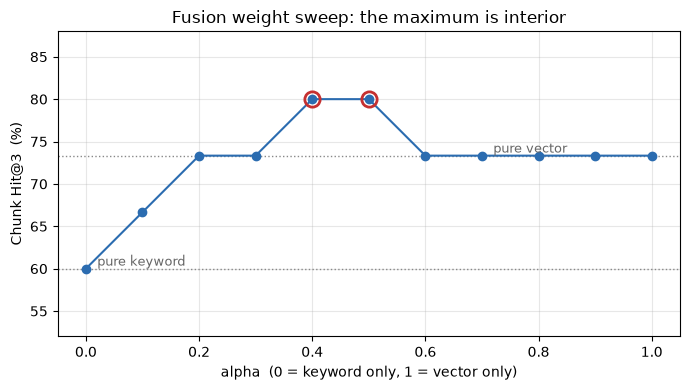

pure keyword (a=0.0):          60.0%
peak         (a=[0.4, 0.5]): 80.0%
pure vector  (a=1.0):          73.3%

interior maximum: +6.7 points over the better endpoint


In [5]:
sweep = sweep_alpha(engine, queries, k=K, pool=POOL)
alphas = [a for a, _ in sweep]
scores = [s * 100 for _, s in sweep]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(alphas, scores, marker="o", color="#2b6cb0", zorder=3)

best = max(scores)
for a, s in zip(alphas, scores):
    if s == best:
        ax.plot(a, s, marker="o", ms=11, mfc="none", mec="#c53030", mew=2, zorder=4)

ax.axhline(scores[0], ls=":", c="#888", lw=1)
ax.axhline(scores[-1], ls=":", c="#888", lw=1)
ax.annotate("pure keyword", (0.02, scores[0]), va="bottom", fontsize=9, color="#666")
ax.annotate("pure vector", (0.72, scores[-1]), va="bottom", fontsize=9, color="#666")

ax.set_xlabel("alpha  (0 = keyword only, 1 = vector only)")
ax.set_ylabel(f"Chunk Hit@{K}  (%)")
ax.set_title("Fusion weight sweep: the maximum is interior")
ax.set_ylim(min(scores) - 8, max(scores) + 8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_alphas = [a for a, s in zip(alphas, scores) if s == best]
print(f"pure keyword (a=0.0):          {scores[0]:.1f}%")
print(f"peak         (a={best_alphas}): {best:.1f}%")
print(f"pure vector  (a=1.0):          {scores[-1]:.1f}%")
print(f"\ninterior maximum: +{best - max(scores[0], scores[-1]):.1f} points over the better endpoint")

The maximum sits in the middle and both endpoints are lower. That interior maximum is
exactly what hybrid retrieval predicts, and unlike the headline numbers it is a property
of the whole curve rather than one query.

## 4. Where the difference comes from

The query set is split three ways by construction: `semantic` queries paraphrase the
answer and avoid its vocabulary, `keyword` queries use literal identifiers, `mixed`
queries do both.

In [6]:
by_type = pd.DataFrame({name: r["by_type"] for name, r in results.items()}).T
counts = pd.Series({q["type"]: sum(1 for x in queries if x["type"] == q["type"]) for q in queries})
by_type.columns = [f"{c} (n={counts[c]})" for c in by_type.columns]
(by_type * 100).round(1)

,keyword (n=4),mixed (n=4),semantic (n=7)
vector-only,100.0,75.0,57.1
fts5-only,75.0,100.0,28.6
bm25okapi-only,100.0,100.0,57.1
hybrid-weighted (a=0.5),100.0,100.0,57.1
hybrid-rrf,100.0,75.0,57.1


`semantic` behaves as designed: keyword search collapses to 28.6% against 57.1% for
vectors, because the passage's own words were deliberately kept out of the query.

`keyword` does **not** behave as designed. The hypothesis was that literal identifiers
would favour BM25, but vectors score 100% there against 75% for FTS5. MiniLM tokenizes a
coined name like `AraSSM` into subwords that are themselves frequent in the paper that
coined it, and on a 50-paper corpus nothing else competes for them. Dense retrieval
failing on rare literal strings is a real phenomenon — it just needs a corpus with
genuine lexical competition to reproduce, and this one is too small and too topically
sparse.

## 5. Per-query detail

In [7]:
per_query = pd.DataFrame({
    name: [x["chunk_rank"] for x in r["per_query"]] for name, r in results.items()
})
per_query.insert(0, "query", [q["query"][:52] for q in queries])
per_query.insert(0, "type", [q["type"] for q in queries])
per_query.insert(0, "qid", [q["qid"] for q in queries])
per_query.fillna("-")

,qid,type,query,vector-only,fts5-only,bm25okapi-only,hybrid-weighted (a=0.5),hybrid-rrf
0,q01,keyword,LongCat-Flash Single Batch Overlap ScMoE,1.0,2.0,2.0,1.0,1.0
1,q02,mixed,replicating hotspot experts at runtime to avoid devi,1.0,2.0,2.0,1.0,1.0
2,q03,semantic,why do some experts stop receiving training signal w,-,-,3.0,-,-
3,q04,mixed,All-to-All metadata and small-GEMM fragmentation whe,-,2.0,2.0,3.0,4.0
4,q05,semantic,once a position has been filled in it can never be r,1.0,5.0,2.0,1.0,2.0
5,q06,mixed,commitment horizon definition tolerance epsilon earl,2.0,1.0,1.0,1.0,1.0
6,q07,keyword,Archer refresh when Hamming distance to the anchor e,1.0,4.0,3.0,1.0,2.0
7,q08,semantic,how much quality and speed does reusing cached state,2.0,3.0,3.0,2.0,3.0
8,q09,keyword,insertion strategy beginning only end only number of,1.0,1.0,1.0,1.0,1.0
9,q10,semantic,spotting untruthful answers by reading a frozen netw,3.0,-,5.0,3.0,1.0


## Conclusion

**Does hybrid beat either leg alone?** On this corpus, yes, but narrowly. Hybrid-weighted
at `alpha=0.5` takes the best Chunk Hit@1 (60.0% vs 53.3% for vectors) and the best MRR
(0.691 vs 0.639), and matches the best Hit@3. The alpha sweep's interior maximum is the
most trustworthy evidence, since it does not depend on any single query.

**What the evaluation cannot show.** 15 queries labelled by one annotator over 50 papers
from a single month of cs.CL. Differences of one or two queries are noise. And the whole
exercise measures retrieval only — whether a generator writes a better answer from these
passages is untested.

**The most useful finding was a negative one.** The first evaluation scored relevance at
paper level and returned a flat 83.3% for all five methods, which looked like a broken
implementation. It was a broken *measurement*: the task was saturated. Fixing the metric
rather than the retriever is what made the comparison mean anything.